# Compare Freeze Srate with current State

## Freeze State

In [50]:
%matplotlib inline
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
import pandas as pd
import kagglehub

In [57]:
df = pd.read_csv("datasets/FreezeState-20250521/World-Stock-Prices-Dataset.csv")
#Filter Brand_Name by apple and filter columns by Date, Close, Brand_Name
df_freeze = df.loc[df["Brand_Name"] == "google", ["Date", "Close", "Brand_Name"]]
df_freeze_preproc = df_freeze.rename(columns={"Date": "timestamp", "Close": "target", "Brand_Name": "item_id"})
df_freeze_preproc["item_id"] = df_freeze_preproc['item_id'].astype("string")
df_freeze_preproc["timestamp"] = df_freeze_preproc['timestamp'].astype("string")
timecut = df_freeze_preproc["timestamp"].str.slice(stop=10) #Cut hh:mm:ss and timezone
df_freeze_preproc["timestamp"] = timecut
df_freeze_preproc["timestamp"] = pd.to_datetime(timecut) #convert string into datetime64
df_freeze_reordered =  df_freeze_preproc[['item_id', 'timestamp', 'target']] #Reordering columns
df_irregular = TimeSeriesDataFrame(
    pd.DataFrame(df_freeze_reordered)
)
df_regular = df_irregular.convert_frequency(freq="D")
df_filled = df_regular.fill_missing_values()
data = TimeSeriesDataFrame.from_data_frame(
    df = df_filled,
    id_column="item_id",
    timestamp_column="timestamp"
)

In [60]:
prediction_length = 45
train_data, test_data = data.train_test_split(prediction_length)

predictor_freeze = TimeSeriesPredictor(prediction_length=prediction_length).fit(
    train_data, presets="bolt_base",
)

Beginning AutoGluon training...
AutoGluon will save models to 'c:\workspace\CrimeMap\AutogluonModels\ag-20250720_123159'
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.1
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          8
GPU Count:          0
Memory Avail:       2.75 GB / 15.70 GB (17.5%)
Disk Space Avail:   73.39 GB / 475.50 GB (15.4%)
Setting presets to: bolt_base

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'hyperparameters': {'Chronos': {'model_path': 'bolt_base'}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 45,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': True,
 'target': 'target',
 'verbosity': 2}

Inferred time series frequency: 'D'
Provided train_data has 7536 rows, 1 time series. Median tim

Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_base]


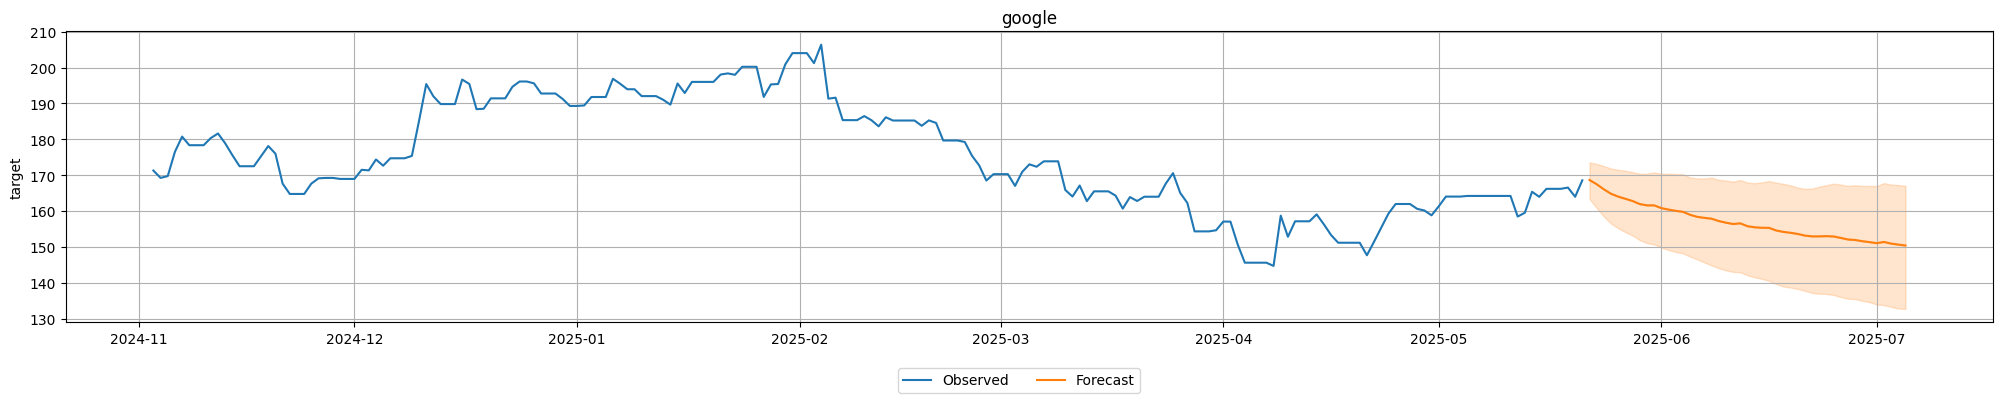

In [61]:
predictions = predictor_freeze.predict(test_data)
predictor_freeze.plot(
    data=data,
    predictions=predictions,
    item_ids=data.item_ids[:2],
    max_history_length=200,
);

## Current State

In [63]:
#Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/world-stock-prices-daily-updating")

print("Path to dataset files:", path)

#Load Data in pandas
data_path = path+"\World-Stock-Prices-Dataset.csv"
stockdata = pd.read_csv(data_path)
#Create DataFrame
df2 = pd.DataFrame(stockdata)
df_current = df2.loc[df2["Brand_Name"] == "google", ["Date", "Close", "Brand_Name"]]
df_current_preproc = df_current.rename(columns={"Date": "timestamp", "Close": "target", "Brand_Name": "item_id"})
df_current_preproc["item_id"] = df_current_preproc['item_id'].astype("string")
df_current_preproc["timestamp"] = df_current_preproc['timestamp'].astype("string")
timecut = df_current_preproc["timestamp"].str.slice(stop=10) #Cut hh:mm:ss and timezone
df_current_preproc["timestamp"] = timecut
df_current_preproc["timestamp"] = pd.to_datetime(timecut) #convert string into datetime64
df_current_reordered =  df_current_preproc[['item_id', 'timestamp', 'target']] #Reordering columns
df_irregular = TimeSeriesDataFrame(
    pd.DataFrame(df_current_reordered)
)
df_regular = df_irregular.convert_frequency(freq="D")
df_filled = df_regular.fill_missing_values()
data = TimeSeriesDataFrame.from_data_frame(
    df = df_filled,
    id_column="item_id",
    timestamp_column="timestamp"
)

<>:7: SyntaxWarning: invalid escape sequence '\W'
<>:7: SyntaxWarning: invalid escape sequence '\W'
C:\Users\s3phi\AppData\Local\Temp\ipykernel_19544\1881970921.py:7: SyntaxWarning: invalid escape sequence '\W'
  data_path = path+"\World-Stock-Prices-Dataset.csv"


Path to dataset files: C:\Users\s3phi\.cache\kagglehub\datasets\nelgiriyewithana\world-stock-prices-daily-updating\versions\400


In [64]:
prediction_length = 60
train_data, test_data = data.train_test_split(prediction_length)

predictor_current = TimeSeriesPredictor(prediction_length=prediction_length).fit(
    train_data, presets="bolt_base",
)

Beginning AutoGluon training...
AutoGluon will save models to 'c:\workspace\CrimeMap\AutogluonModels\ag-20250720_123251'
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.1
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          8
GPU Count:          0
Memory Avail:       2.70 GB / 15.70 GB (17.2%)
Disk Space Avail:   73.39 GB / 475.50 GB (15.4%)
Setting presets to: bolt_base

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'hyperparameters': {'Chronos': {'model_path': 'bolt_base'}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 60,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': True,
 'target': 'target',
 'verbosity': 2}

Inferred time series frequency: 'D'
Provided train_data has 7564 rows, 1 time series. Median tim

Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_base]


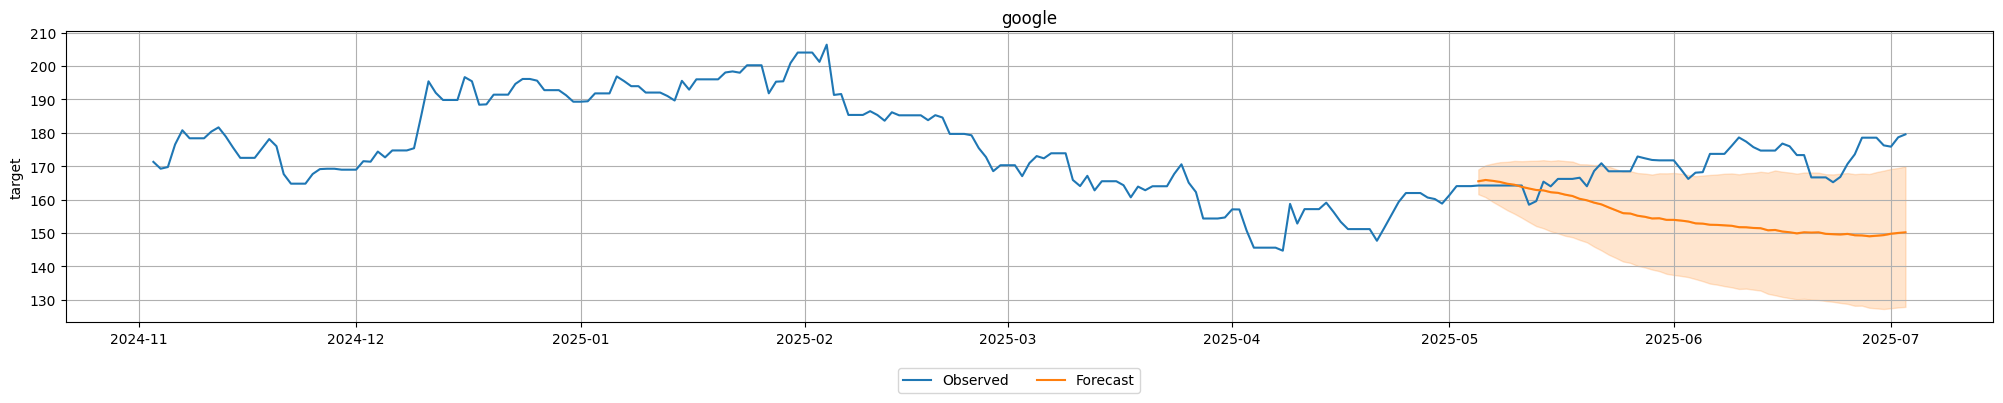

In [67]:
predictions = predictor_current.predict(train_data)
predictor_current.plot(
    data=data,
    predictions=predictions,
    item_ids=data.item_ids[:2],
    max_history_length=243,
);

## Fine Tuning

In [48]:
prediction_length = 60
train_data, test_data = data.train_test_split(prediction_length)

predictor = TimeSeriesPredictor(prediction_length=prediction_length, freq="D").fit(
    train_data, presets="bolt_base", hyperparameters={"Chronos": {"fine_tune": True, "fine_tune_lr": 1e-5, "fine_tune_steps": 7000}},
    time_limit=30,
)

Beginning AutoGluon training... Time limit = 30s
AutoGluon will save models to 'c:\workspace\CrimeMap\AutogluonModels\ag-20250719_171512'
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.1
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          8
GPU Count:          0
Memory Avail:       2.60 GB / 15.70 GB (16.6%)
Disk Space Avail:   79.95 GB / 475.50 GB (16.8%)
Setting presets to: bolt_base

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'freq': 'D',
 'hyperparameters': {'Chronos': {'fine_tune': True,
                                 'fine_tune_lr': 1e-05,
                                 'fine_tune_steps': 7000}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 60,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': True

Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_base]


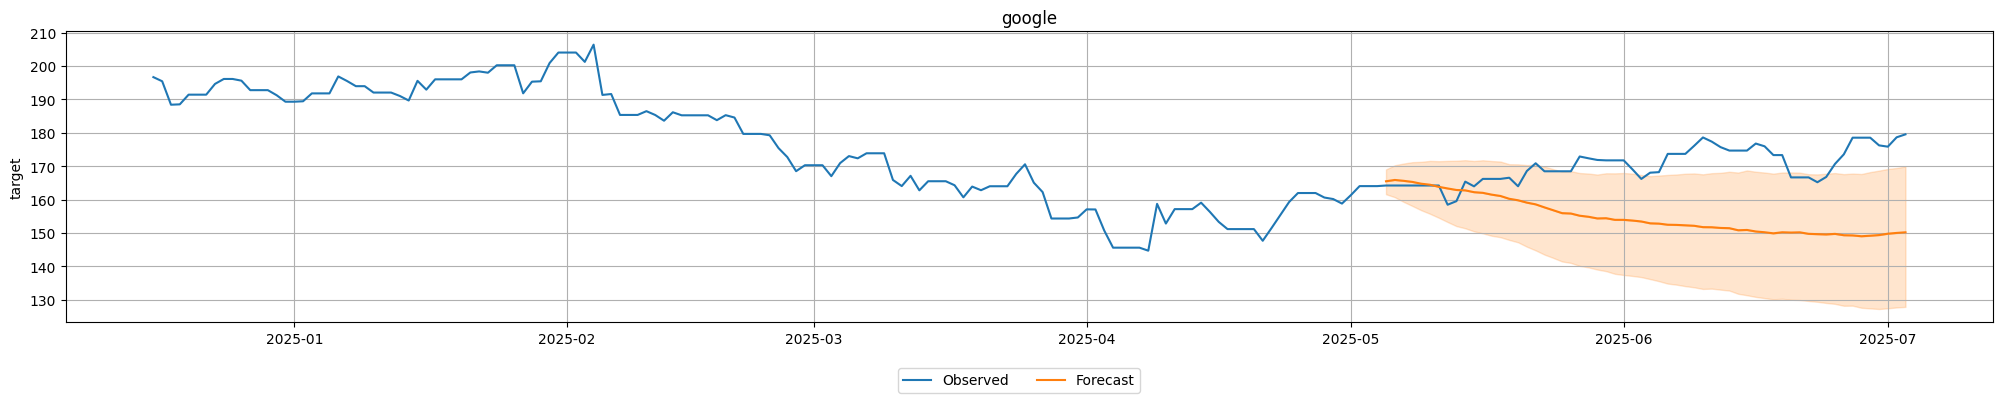

In [49]:
predictions = predictor_current.predict(train_data)
predictor_current.plot(
    data=data,
    predictions=predictions,
    item_ids=data.item_ids[:2],
    max_history_length=200,
);